## Block below will convert the folder of numpy arrays to a wav file you can listen to  

In [44]:
import numpy as np
import os
from scipy.io import wavfile
import glob

# 1. Setup paths
folder_path = 'viz/test/'
output_filename = 'test.wav'
sample_rate = 8000  # Adjust this if your recording rate was different

# 2. Get all .npy files and sort them
# Sorting ensures the "time" suffix in your filenames keeps the audio in order
files = sorted(glob.glob(os.path.join(folder_path, "vibration_*.npy")))

if not files:
    print("No files found! Check your directory path.")
else:
    print(f"Found {len(files)} files. Processing...")

    # 3. Load and concatenate
    audio_segments = []
    for f in files:
        segment = np.load(f)
        audio_segments.append(segment)
    
    # Combine all 1-second arrays into one long array
    full_audio = np.concatenate(audio_segments)

    # 4. Normalize (Prevents ear-piercing distortion/clipping)
    full_audio = full_audio - np.mean(full_audio)
    # Scales the data to fit between -1.0 and 1.0
    max_amplitude = np.max(np.abs(full_audio))
    if max_amplitude > 0:
        full_audio = full_audio / max_amplitude

    # 5. Export to WAV
    wavfile.write(output_filename, sample_rate, full_audio.astype(np.float32))
    print(f"Success! Saved {len(files)} seconds of audio to {output_filename}")

Found 8 files. Processing...
Success! Saved 8 seconds of audio to test.wav


### Waveform visualization

In [ ]:
import matplotlib.pyplot as plt

# Using 'full_audio' from the previous step
plt.figure(figsize=(15, 5))
plt.plot(full_audio)
plt.title("Vibration Signal")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.ylim(-1,1)
plt.show()

### Spectrogram

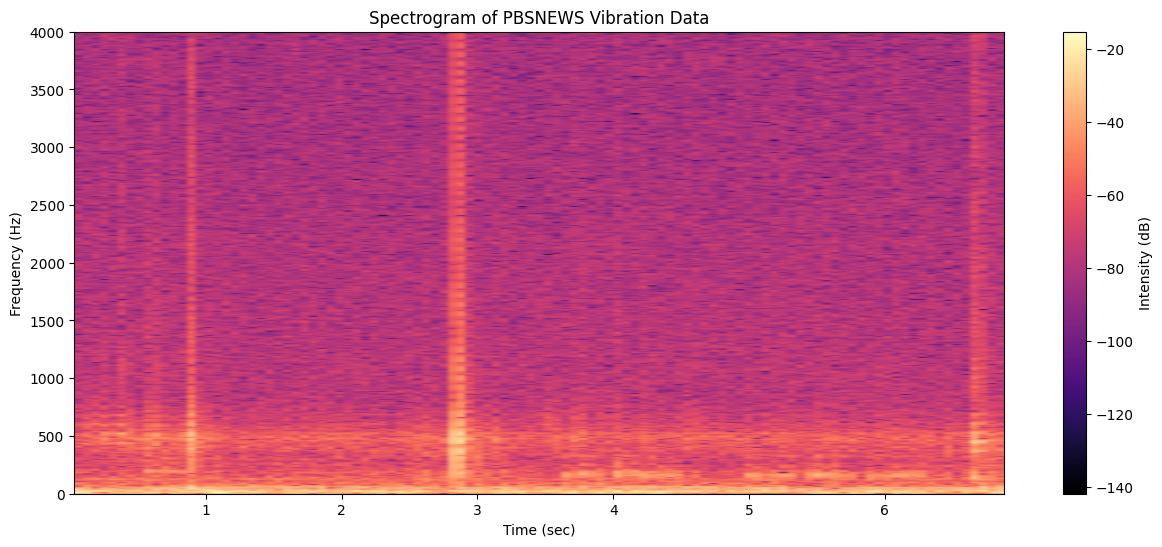

In [46]:
plt.figure(figsize=(15, 6))
plt.specgram(full_audio, Fs=sample_rate, NFFT=1024, noverlap=512, cmap='magma')
plt.title("Spectrogram of PBSNEWS Vibration Data")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (sec)")
plt.colorbar(label="Intensity (dB)")
plt.show()